In [1]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import nnls
import os
import re
import random

import importlib
import cleaning as clean
from collections import Counter
from sklearn.metrics import confusion_matrix


In [2]:
## 🛻 Data loading
df = pd.read_csv("../data/signatures_GRCh37_SBS88_SBS1_SBS5_SBS18.csv", sep=",")
print("\033[4m Check summary statistics: \033[0m\n", df.describe(), "\n")
print("\033[4m Check data consistency: \033[0m\n", np.sum(df, 0))
df.head()
## Note that the Contect labels are not in the same order as in the Webpage
# Adding the normal colon, with weights for SBS1, SBS5 and SBS18, 0.4, 0.4, 0.2
df["Normal_colon"] = 0.4*df["SBS1_GRCh37"] + 0.4*df["SBS5_GRCh37"] + 0.2*df["SBS18_GRCh37"]
print("Sum of all elements should be 1: ", sum(df["Normal_colon"]))
df.head()
# Reordering the Context column so it matches the one in the web
# which is ordered according to alphabetical order of the single
# base substitution first
def basis_change_first(a):
    return a[1:-1]+a[0]+a[-1]

df["context_ordered"] = df["Context"].map(basis_change_first)
df.head()

final_df = df.sort_values(by=["context_ordered"]).reset_index(drop=True).drop("context_ordered", axis=1)
final_df.head()

 Check summary statistics: 
        SBS88_GRCh37   SBS1_GRCh37  SBS5_GRCh37  SBS18_GRCh37
count  9.600000e+01  9.600000e+01    96.000000     96.000000
mean   1.041667e-02  1.041667e-02     0.010417      0.010417
std    2.640885e-02  4.832854e-02     0.008391      0.020818
min    1.000000e-18  2.230396e-16     0.001510      0.000037
25%    1.000000e-18  6.313620e-05     0.004819      0.001901
50%    1.731102e-03  2.565455e-04     0.007623      0.003197
75%    6.347374e-03  1.350240e-03     0.013547      0.008433
max    1.696480e-01  3.650648e-01     0.046191      0.122080 

 Check data consistency: 
 Context         A[C>A]AA[C>A]CA[C>A]GA[C>A]TA[C>G]AA[C>G]CA[C>...
SBS88_GRCh37                                                  1.0
SBS1_GRCh37                                                   1.0
SBS5_GRCh37                                                   1.0
SBS18_GRCh37                                                  1.0
dtype: object
Sum of all elements should be 1:  0.9999999999999

,Context,SBS88_GRCh37,SBS1_GRCh37,SBS5_GRCh37,SBS18_GRCh37,Normal_colon
0,A[C>A]A,1.000000e-18,0.000886,0.011998,0.051534,0.015460
1,A[C>A]C,1.000000e-18,0.002280,0.009438,0.015810,0.007849
2,A[C>A]G,1.000000e-18,0.000177,0.001850,0.002432,0.001297
3,A[C>A]T,1.731102e-03,0.001280,0.006609,0.021414,0.007438
4,C[C>A]A,1.000000e-18,0.000312,0.007429,0.074049,0.017906


In [3]:
# Adding the normal colon, with weights for SBS1, SBS5 and SBS18, 0.4, 0.4, 0.2
df["Normal_colon"] = 0.4*df["SBS1_GRCh37"] + 0.4*df["SBS5_GRCh37"] + 0.2*df["SBS18_GRCh37"]
print("Sum of all elements should be 1: ", sum(df["Normal_colon"]))
df.head()

Sum of all elements should be 1:  0.9999999999999976


,Context,SBS88_GRCh37,SBS1_GRCh37,SBS5_GRCh37,SBS18_GRCh37,Normal_colon,context_ordered
0,A[C>A]A,1.000000e-18,0.000886,0.011998,0.051534,0.015460,[C>A]AA
1,A[C>A]C,1.000000e-18,0.002280,0.009438,0.015810,0.007849,[C>A]AC
2,A[C>A]G,1.000000e-18,0.000177,0.001850,0.002432,0.001297,[C>A]AG
3,A[C>A]T,1.731102e-03,0.001280,0.006609,0.021414,0.007438,[C>A]AT
4,A[C>G]A,1.000000e-18,0.001860,0.010098,0.001731,0.005130,[C>G]AA


In [4]:
# Reordering the Context column so it matches the one in the web
# which is ordered according to alphabetical order of the single
# base substitution first
def basis_change_first(a):
    return a[1:-1]+a[0]+a[-1]

df["context_ordered"] = df["Context"].map(basis_change_first)
df.head()

,Context,SBS88_GRCh37,SBS1_GRCh37,SBS5_GRCh37,SBS18_GRCh37,Normal_colon,context_ordered
0,A[C>A]A,1.000000e-18,0.000886,0.011998,0.051534,0.015460,[C>A]AA
1,A[C>A]C,1.000000e-18,0.002280,0.009438,0.015810,0.007849,[C>A]AC
2,A[C>A]G,1.000000e-18,0.000177,0.001850,0.002432,0.001297,[C>A]AG
3,A[C>A]T,1.731102e-03,0.001280,0.006609,0.021414,0.007438,[C>A]AT
4,A[C>G]A,1.000000e-18,0.001860,0.010098,0.001731,0.005130,[C>G]AA


In [5]:
final_df = df.sort_values(by=["context_ordered"]).reset_index(drop=True).drop("context_ordered", axis=1)
final_df.head()

,Context,SBS88_GRCh37,SBS1_GRCh37,SBS5_GRCh37,SBS18_GRCh37,Normal_colon
0,A[C>A]A,1.000000e-18,0.000886,0.011998,0.051534,0.015460
1,A[C>A]C,1.000000e-18,0.002280,0.009438,0.015810,0.007849
2,A[C>A]G,1.000000e-18,0.000177,0.001850,0.002432,0.001297
3,A[C>A]T,1.731102e-03,0.001280,0.006609,0.021414,0.007438
4,C[C>A]A,1.000000e-18,0.000312,0.007429,0.074049,0.017906


In [6]:
reference_sig = final_df["SBS88_GRCh37"]
print(reference_sig, sum(reference_sig))

0     1.000000e-18
1     1.000000e-18
2     1.000000e-18
3     1.731102e-03
4     1.000000e-18
          ...     
91    1.327178e-02
92    3.058280e-02
93    2.077323e-02
94    1.000000e-18
95    1.021350e-01
Name: SBS88_GRCh37, Length: 96, dtype: float64 0.9999999999999981


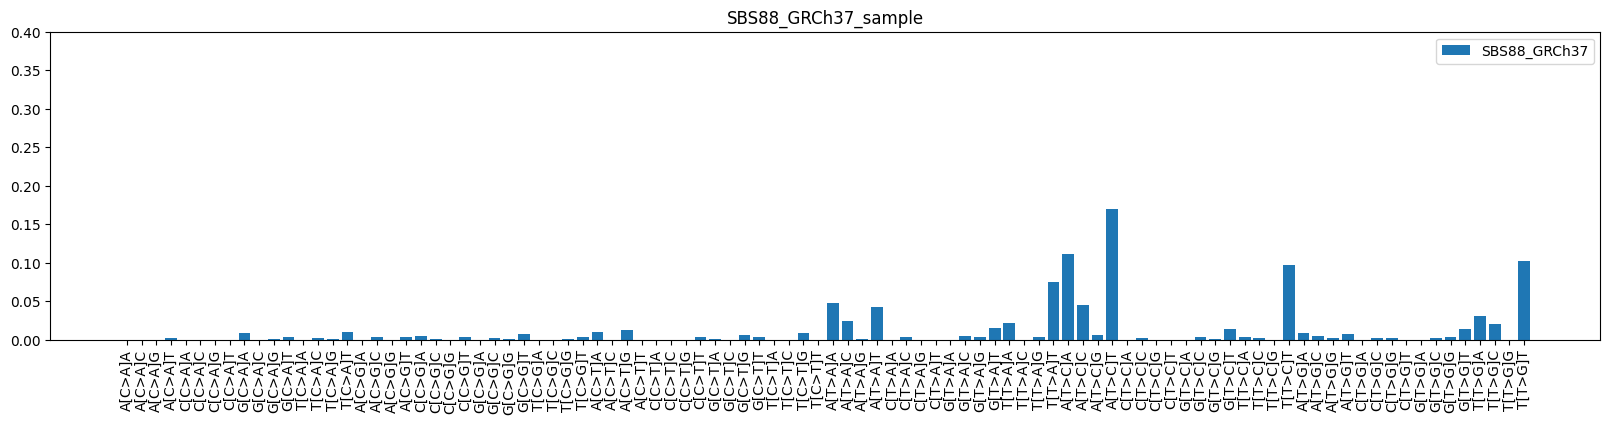

In [7]:
def vis_data(data, x_axis, labels=["Test"], title="Test", alpha=1):
    fig = plt.figure(figsize=(20, 4))
    ax = fig.add_subplot()
    for i in range(len(data)):
        ax.bar(x_axis, data[i], label=labels[i], alpha=alpha)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(top=0.4)

    plt.legend()
    plt.title(title)
    plt.show()

vis_data([reference_sig], final_df["Context"], ["SBS88_GRCh37"], "SBS88_GRCh37_sample")

In [13]:
def load_NM_data(mn_get=10, directory_str="../generated_data"):
    dfs = []
    alphas = []
    
    directory = os.fsencode(directory_str)
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        mn, a = filename[17:].split("_a")
        a = a[:-4]
        # For the lognormal distribution special case 
        # (in this case since is the only with a=0.1, will not do anything more, althoough it would be cleaner to generalize more this function)
        if len(a) > 4:
            a = a[:3]
        # print(nm, a)
        # print(filename[17:].split("_a"))
        if int(mn) == mn_get:
            print(mn)
            dfs.append(pd.read_csv(os.path.join(directory_str, filename)).iloc[:, 1:])
            alphas.append(float(a))
            continue
        else:
            continue

    return dfs, alphas

mn_get = 3
dfs, alphas = load_NM_data(mn_get=mn_get)
print(len(alphas), alphas) # Checking there should be three loaded datasets 
print(np.sum(dfs[0].head(), axis=1)) # Checking, shoud add to the value of mn_get = Mutation Number 
dfs[0].head()


3
3
3
3
3
5 [0.08, 0.1, 0.5, 0.0, 1.0]
0    3
1    3
2    3
3    3
4    3
dtype: int64


,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# normalize dataframes to get signatures
normalized_dfs = []
for df in dfs:
    normalized_dfs.append(df/mn_get)
print(np.sum(normalized_dfs[0].head(), axis=1)) # Checking normalized row adds up to 1

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


In [21]:
# SciPy has a built in KL Divergence
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html
import scipy.spatial.distance as scipy_dist
cos_sim = scipy_dist.cosine
KLDiv = stats.entropy

distrib = "SBS88"

def ABC_for_known_data(df_data, obs_sig, f_comparison = cos_sim, tol = 0.95):

    # Store accept (1) and reject (0)
    classifications = np.zeros(len(df_data))

    for i, row in df_data.iterrows():
        # For each row compare to the obs_signature
        difference_score = f_comparison(obs_sig, row)
        # print(difference_score)
        if (difference_score < tol):
            classifications[i] = 1

    # End loop
    accepts_perc = np.sum(classifications)/len(classifications)
    return accepts_perc, classifications

# ================

# Test for different alpha (obviously for a = 1 low mutation number s still good)
test_alpha = 0.08
# print(alphas.index(test_alpha))
accepts_perc, classifications = ABC_for_known_data(normalized_dfs[alphas.index(test_alpha)], reference_sig)
print("Percentage of accepted samples (a=0.08):", accepts_perc)
print(Counter(classifications))

accepts_perc_null, classifications = ABC_for_known_data(normalized_dfs[alphas.index(0)], reference_sig)
print("Percentage of accepted samples (a=0):", accepts_perc_null)
print(Counter(classifications))

print(accepts_perc-accepts_perc_null)

Percentage of accepted samples (a=0.08): 0.4263
Counter({np.float64(0.0): 5737, np.float64(1.0): 4263})
Percentage of accepted samples (a=0): 0.3176
Counter({np.float64(0.0): 6824, np.float64(1.0): 3176})
0.10870000000000002


## Find best tol and compare results of classification

In [22]:
def conf_matrix_values(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()
    return (tn, fp, fn, tp)

def find_best_tol_evaluate(dfs, alphas, tols, f_comparison=cos_sim):
    best_tols = np.zeros(len(dfs))
    scores = [(0, 0)]*len(dfs)
    for alpha_idx in range(len(alphas)):
        if alphas[alpha_idx] == 0:
            continue
        print(f"Processig a={alphas[alpha_idx]}...")
        for tol in tols:
            accepts_perc, classifications = ABC_for_known_data(dfs[alpha_idx], reference_sig, f_comparison=f_comparison, tol=tol)
            accepts_perc_null, classifications_null = ABC_for_known_data(dfs[alphas.index(0)], reference_sig, f_comparison=f_comparison, tol=tol)
            eval_metric = accepts_perc - accepts_perc_null # Since we want TP% to be high and FP% to be low
            if eval_metric >= scores[alpha_idx][0]:
                best_tols[alpha_idx] = tol
                scores[alpha_idx] = (eval_metric, conf_matrix_values(
                    np.concatenate([np.ones(len(classifications)), np.zeros(len(classifications_null))]), np.concatenate([classifications, classifications_null])))

    return best_tols, scores

print(alphas)
tols = np.linspace(0.025, 0.95, 38)
# tols = np.linspace(0.925, 0.95, 20)
print(tols)
best_tols, scores = find_best_tol_evaluate(dfs, alphas, tols)
# best_tols, scores = find_best_tol_evaluate(dfs, alphas, tols, KLDiv)
print(best_tols)
print(scores)

[0.08, 0.1, 0.5, 0.0, 1.0]
[0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275 0.3
 0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575 0.6
 0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875 0.9
 0.925 0.95 ]
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
[0.925 0.925 0.925 0.    0.875]
[(np.float64(0.11259999999999998), (7757, 2243, 6631, 3369)), (np.float64(0.15439999999999998), (7757, 2243, 6213, 3787)), (np.float64(0.5694999999999999), (7757, 2243, 2062, 7938)), (0, 0), (np.float64(0.7823), (8178, 1822, 355, 9645))]


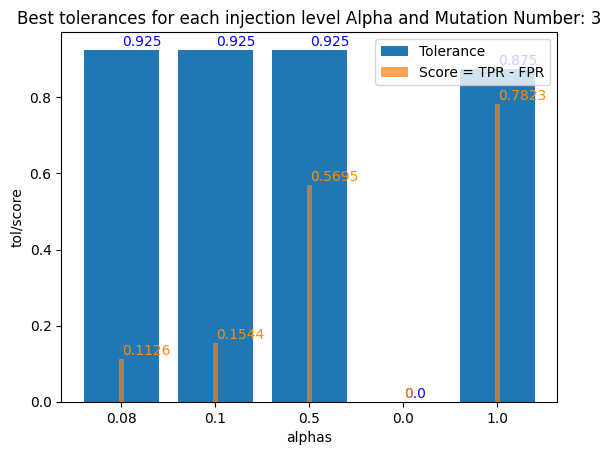

In [23]:
# Function to add value labels on top of bars
def add_labels(x, y, color):
    for i in range(len(x)):
        plt.text(i+0.01, y[i]+0.01, np.round(y[i], 4), color=color)  # Placing text slightly above the bar

plt.bar(np.asarray(alphas, str), best_tols, label="Tolerance")
plt.bar(np.asarray(alphas, str), [x[0] for x in scores], width=0.05, alpha=0.7, label="Score = TPR - FPR")
add_labels(np.asarray(alphas, str), best_tols, "blue")
add_labels(np.asarray(alphas, str), [x[0] for x in scores], "darkorange")
plt.legend()
plt.title(f"Best tolerances for each injection level Alpha and Mutation Number: {mn_get}")
plt.ylabel("tol/score")
plt.xlabel("alphas")
plt.show()

## Final Full process for Mutation Number determination

In [24]:
mutation_number_list = [3, 5, 10, 50, 100, 200, 500, 1000, 5000, 10000, 100000]
best_tols_list, scores_list = [], []

for mn_get in mutation_number_list:
    dfs, alphas = load_NM_data(mn_get=mn_get)
    normalized_dfs = []
    print(f"Processing Mutation Number: {mn_get}...")
    for df in dfs:
        normalized_dfs.append(df/mn_get)
        # print(alphas)
    tols = np.linspace(0.025, 0.95, 38)
    # tols = np.linspace(0.925, 0.95, 20)
    # print(tols)
    best_tols, scores = find_best_tol_evaluate(dfs, alphas, tols)
    # best_tols, scores = find_best_tol_evaluate(dfs, alphas, tols, KLDiv)
    # print(best_tols)
    # print(scores)
    best_tols_list.append(best_tols)
    scores_list.append(scores)


3
3
3
3
3
Processing Mutation Number: 3...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
5
5
5
5
5
Processing Mutation Number: 5...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
10
10
10
10
10
Processing Mutation Number: 10...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
50
50
50
50
50
Processing Mutation Number: 50...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
100
100
100
100
100
Processing Mutation Number: 100...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
200
200
200
200
200
Processing Mutation Number: 200...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
500
500
500
500
500
Processing Mutation Number: 500...
Processig a=0.08...
Processig a=0.1...
Processig a=0.5...
Processig a=1.0...
1000
1000
1000
1000
1000
Processing Mutation Number: 1000...
Processig a=0.08...
Processig a=0.1...
Processig a=

In [25]:
print(best_tols_list[0])
print(scores_list[0])

[0.925 0.925 0.925 0.    0.875]
[(np.float64(0.11259999999999998), (7757, 2243, 6631, 3369)), (np.float64(0.15439999999999998), (7757, 2243, 6213, 3787)), (np.float64(0.5694999999999999), (7757, 2243, 2062, 7938)), (0, 0), (np.float64(0.7823), (8178, 1822, 355, 9645))]


In [26]:
print(len(best_tols_list))
cols = ["MutNum", "Alpha", "Best_tol", "Best_score", "tn", "fp", "fn", "tp"]
all_data_list = []
for element_idx in range(len(best_tols_list)):
    for alpha_idx in range(len(alphas)):
        if alphas[alpha_idx] == 0:
            continue
        all_data_list.append([mutation_number_list[element_idx], alphas[alpha_idx], best_tols_list[element_idx][alpha_idx],
                              scores_list[element_idx][alpha_idx][0], scores_list[element_idx][alpha_idx][1][0], scores_list[element_idx][alpha_idx][1][1],
                              scores_list[element_idx][alpha_idx][1][2], scores_list[element_idx][alpha_idx][1][3]])
        
final_evaluation_df = pd.DataFrame(all_data_list, columns=cols)
final_evaluation_df.to_csv("../data/mn_evaluation.csv")

final_evaluation_df.head()

11


,MutNum,Alpha,Best_tol,Best_score,tn,fp,fn,tp
0,3,0.08,0.925,0.1126,7757,2243,6631,3369
1,3,0.10,0.925,0.1544,7757,2243,6213,3787
2,3,0.50,0.925,0.5695,7757,2243,2062,7938
3,3,1.00,0.875,0.7823,8178,1822,355,9645
4,5,0.08,0.925,0.1644,6642,3358,4998,5002


In [27]:
specific_alpha_1 = final_evaluation_df.loc[final_evaluation_df["Alpha"] == 0.08].reset_index(drop=True)
specific_alpha_2 = final_evaluation_df.loc[final_evaluation_df["Alpha"] == 0.5].reset_index(drop=True)
specific_alpha_3 = final_evaluation_df.loc[final_evaluation_df["Alpha"] == 1].reset_index(drop=True)
specific_alpha_4 = final_evaluation_df.loc[final_evaluation_df["Alpha"] == 0.1].reset_index(drop=True)

specific_alpha_3.head()

,MutNum,Alpha,Best_tol,Best_score,tn,fp,fn,tp
0,3,1.0,0.875,0.7823,8178,1822,355,9645
1,5,1.0,0.675,0.8762,9669,331,907,9093
2,10,1.0,0.625,0.9677,9809,191,132,9868
3,50,1.0,0.525,1.0000,10000,0,0,10000
4,100,1.0,0.550,1.0000,10000,0,0,10000


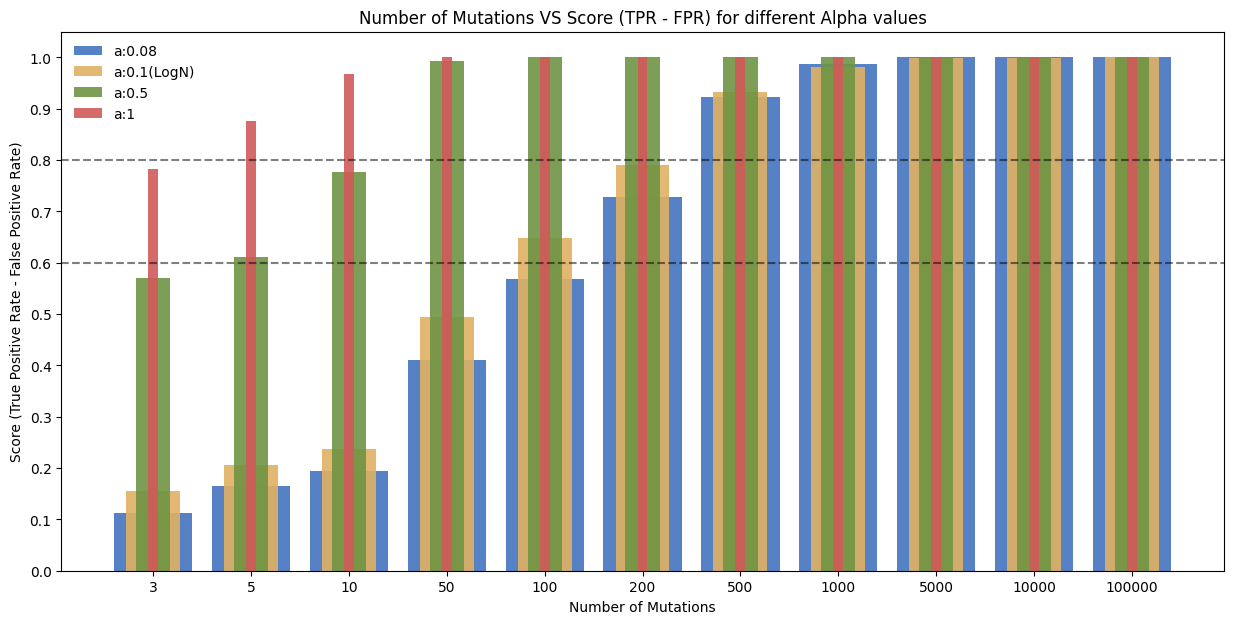

In [142]:
plt.axhline(0.6, linestyle="dashed", color="black", alpha=0.5)
plt.axhline(0.8, linestyle="dashed", color="black", alpha=0.5)
plt.bar(np.asarray(specific_alpha_1["MutNum"], str), specific_alpha_1["Best_score"], label="a:0.08", color="#5681c4")
plt.bar(np.asarray(specific_alpha_4["MutNum"], str), specific_alpha_4["Best_score"], width=0.55, alpha=0.9, label="a:0.1(LogN)", color="#e0b163")
plt.bar(np.asarray(specific_alpha_2["MutNum"], str), specific_alpha_2["Best_score"], width=0.35, alpha=0.9, label="a:0.5", color="#6f9443")
plt.bar(np.asarray(specific_alpha_3["MutNum"], str), specific_alpha_3["Best_score"], width=0.1, alpha=0.9, label="a:1", color="#d15a5a")

plt.title("Number of Mutations VS Score (TPR - FPR) for different Alpha values")
plt.legend(framealpha=0)
plt.xlabel("Number of Mutations")
plt.ylabel("Score (True Positive Rate - False Positive Rate)")
plt.yticks(np.linspace(0, 1, 11))
plt.rcParams['figure.figsize'] = [15, 7]
plt.show()